# Transient Temperature Simulation in an Open District Heating Network

This tutorial demonstrates a transient temperature simulation of a simple open district heating network with pandapipes.

The network consists of:

- one external grid,
- three pipes,
- two consumers,
- and four junctions.

The goal of this example is to show how the temperature propagates through the network over time and how the system slowly approaches a stationary thermal state.

# Network Structure

The following figure shows the topology of the network used in this example.

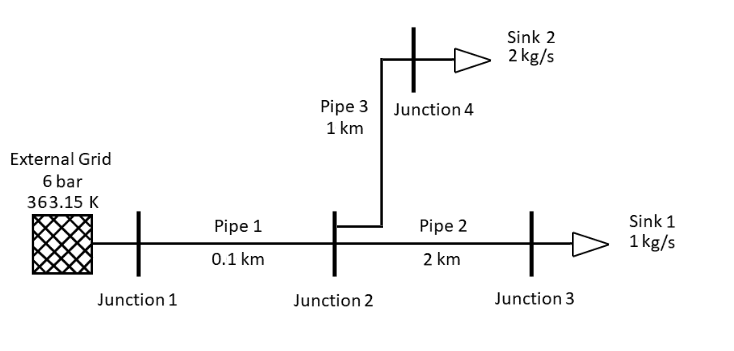

# Import Required Modules

First, pandapipes and the required libraries are imported.

In [1]:
import pandapipes
import numpy as np

from pandapipes.component_models import Pipe
from pandapipes.idx_node import PINIT
from pandapipes.idx_branch import MDOTINIT

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

# Network Creation

An empty network with water as working fluid is created.

In [2]:
net = pandapipes.create_empty_network("net")

pandapipes.create_fluid_from_lib(net, "water", overwrite=True)

# Junctions

Four junctions are created.
Initially, the complete network starts with a temperature of 20 °C.

In [3]:
junction1 = pandapipes.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 1")
junction2 = pandapipes.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 2")
junction3 = pandapipes.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 3")
junction4 = pandapipes.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 4")

# External Grid

The external grid continuously feeds hot water with a temperature of 90 °C into the network.

In [4]:
pandapipes.create_ext_grid(
    net,
    junction=junction1,
    p_bar=6,
    t_k=363.15,
    name="External Grid",
    type="pt"
)

np.int64(0)

# Consumers

Two sinks are used as thermal consumers.

They remove mass flow from the network.

In [5]:
pandapipes.create_sink(net, junction=junction3, mdot_kg_per_s=1, name="Sink 1")

pandapipes.create_sink(net, junction=junction4, mdot_kg_per_s=2, name="Sink 2")

np.int64(1)

# Pipes

Three pipes are used to connect the junctions.

The parameter sections is important for the transient simulation.

Each pipe is internally divided into several sections. This allows pandapipes to calculate and visualize the temperature distribution inside the pipes.

In [6]:
pandapipes.create_pipe_from_parameters(net, from_junction=junction1, to_junction=junction2, length_km=0.1, inner_diameter_mm=75, k_mm=0.025, sections=5, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 1")

pandapipes.create_pipe_from_parameters(net, from_junction=junction2, to_junction=junction3, length_km=2, inner_diameter_mm=50, k_mm=0.025, sections=4, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 2")

pandapipes.create_pipe_from_parameters(net, from_junction=junction2, to_junction=junction4, length_km=1, inner_diameter_mm=100, k_mm=0.025, sections=8, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 3")

np.int64(2)

# Hydraulic Calculation

Before the transient simulation starts, the hydraulic state of the network is calculated.

In [7]:
pandapipes.pipeflow(
    net,
    mode="hydraulics",
    transient=False,
    stop_condition="tol",
    iter=100,
    friction_model="colebrook",
    nonlinear_method="automatic",
    tol_p=1e-4,
    tol_m=1e-4
)

Afterwards, the hydraulic solution is stored.

In [8]:
sol_vec = np.r_[
    net["_pit"]["node"][:, PINIT],
    net["_pit"]["branch"][:, MDOTINIT]
]

## Visualization Function

In [9]:
# Uncomment plt.show() if you want to display the figure interactively.
def plot_temperature_snapshot(net, time_s):
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin=293.15, vmax=363.15)

    coords = {
        0: (0.0, 0.0),     # Junction 1
        1: (1.0, 0.0),     # Junction 2
        2: (2.0, 0.6),     # Junction 3
        3: (2.0, -0.6),    # Junction 4
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    for pipe_idx in net.pipe.index:
        from_j = net.pipe.at[pipe_idx, "from_junction"]
        to_j = net.pipe.at[pipe_idx, "to_junction"]

        x0, y0 = coords[from_j]
        x1, y1 = coords[to_j]

        pipe_results = Pipe.get_internal_results(net, [pipe_idx])
        tinit = pipe_results["TINIT"]

        internal_temps = tinit[:, 1] if tinit.ndim == 2 else tinit

        t_from = net.res_junction.at[from_j, "t_k"]
        t_to = net.res_junction.at[to_j, "t_k"]
        temps = np.r_[t_from, internal_temps, t_to]

        xs = np.linspace(x0, x1, len(temps))
        ys = np.linspace(y0, y1, len(temps))

        points = np.array([xs, ys]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        segment_temps = (temps[:-1] + temps[1:]) / 2

        lc = LineCollection(
            segments,
            cmap=cmap,
            norm=norm,
            linewidth=3
        )
        lc.set_array(segment_temps)
        ax.add_collection(lc)

        ax.scatter(xs, ys, c=temps, cmap=cmap, norm=norm, s=45, zorder=3)

    for j, (x, y) in coords.items():
        temp = net.res_junction.at[j, "t_k"]
        ax.scatter(x, y, c=[temp], cmap=cmap, norm=norm,
                   s=120, edgecolor="black", zorder=4)
        ax.text(x, y + 0.08, f"J{j+1}", ha="center")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Temperature [K]")

    ax.set_title(f"Temperature distribution with pipe sections at t = {time_s} s", pad= 20)
    ax.set_aspect("equal")
    ax.axis("off")

    # plt.show()
    plt.close(fig)

# Transient Temperature Simulation

The transient temperature calculation is performed with a timestep of 60 seconds.

In [12]:
net.junction.loc[:, "told_k"] = net.junction["tfluid_k"]

dt = 60
t_end = 18000
for t in range(dt, t_end + dt, dt):

    pandapipes.pipeflow(
        net, stop_condition="tol", iter=100, friction_model="colebrook",
        mode="heat", sol_vec=sol_vec, transient=True, dt=dt,
        simulation_time_step=t, ambient_temperature=273.15 + 10,
        nonlinear_method="automatic", tol_p=1e-4, tol_m=1e-4, tol_T=1e-3
    )

    if t in [60, 300, 1200, 2400, 3600, 4500, 5400, 7200, 9000, 12000, 18000]:
        plot_temperature_snapshot(net, t)

    # print(net.res_junction["t_k"])

    net.junction.loc[:, "told_k"] = net.res_junction["t_k"].values
    net.junction.loc[:, "tfluid_k"] = net.res_junction["t_k"].values

# Temperature Distribution During the Simulation

The following figure shows the temperature distribution inside the network at different timesteps.
The internal pipe sections are visualized explicitly.

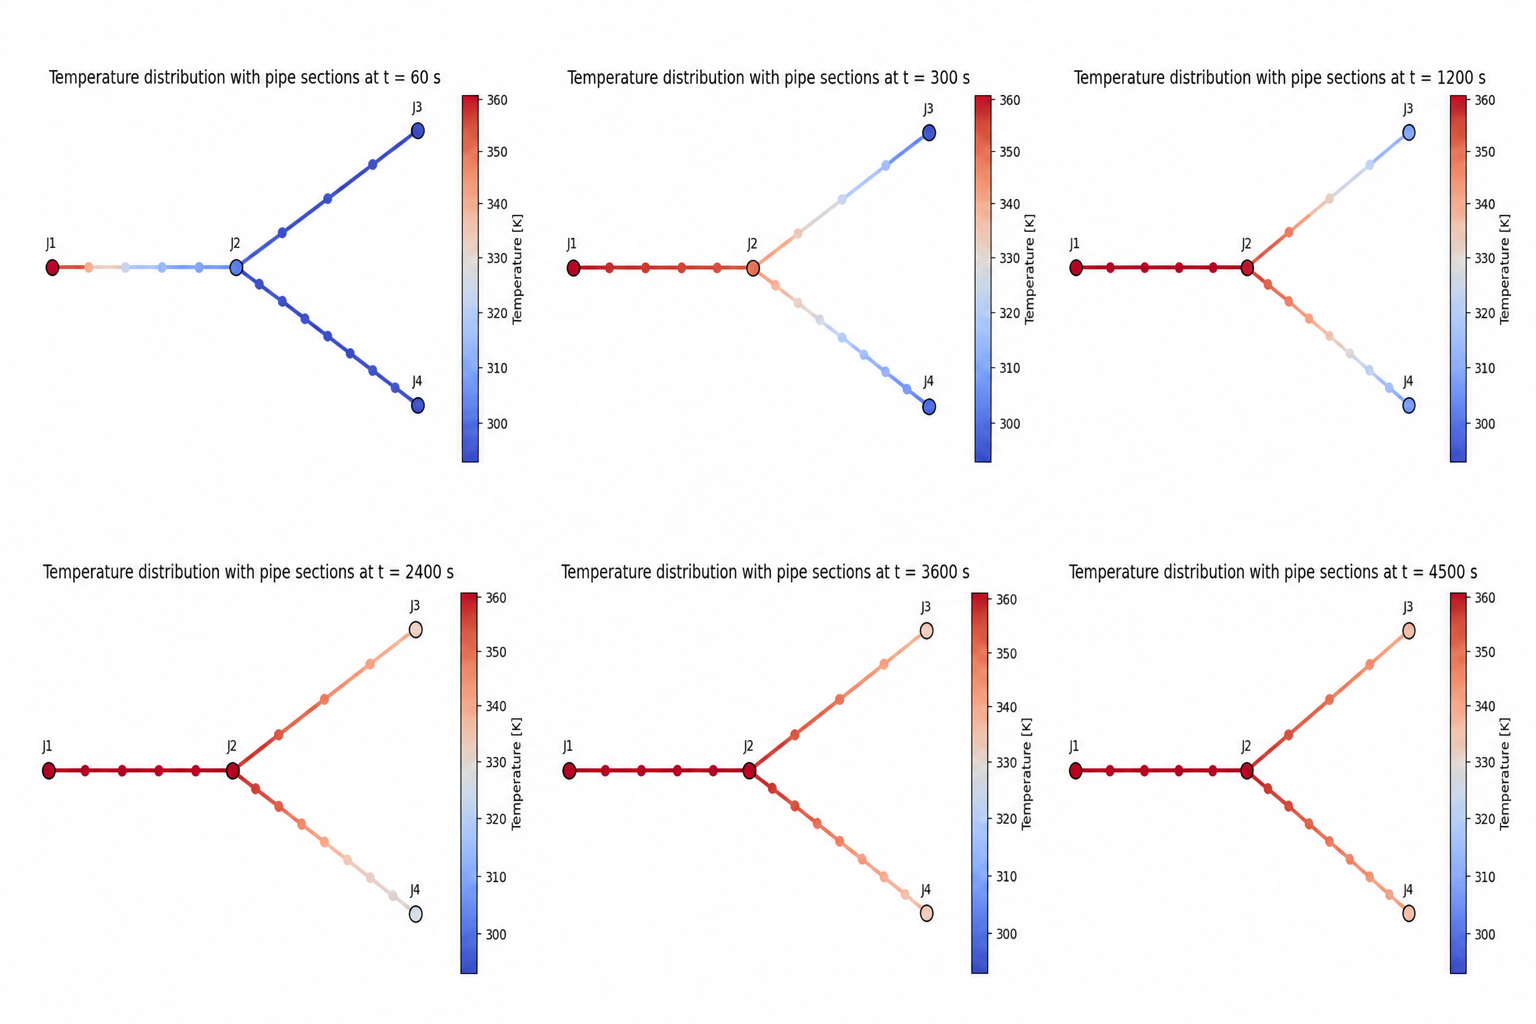

# Junction Temperatures During the Simulation

The following table shows the junction temperatures during the transient simulation.

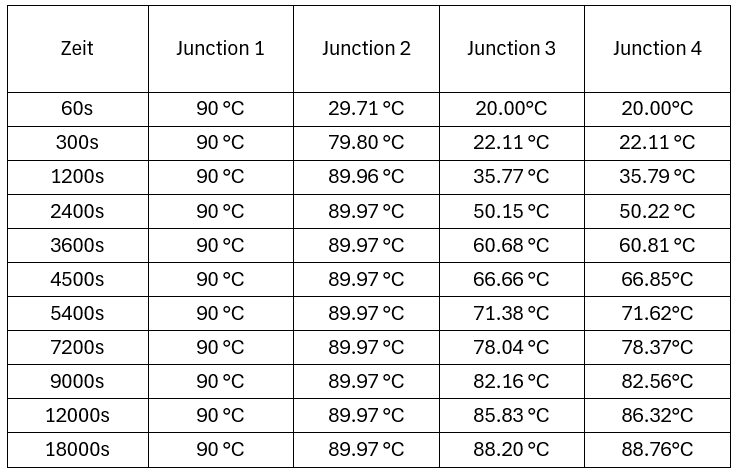

# Discussion

The results show a physically plausible transient temperature behavior. The junction close to the external grid heats up very quickly because hot water is directly injected into the network. The other junctions heat up more slowly because the hot water first needs to travel through the pipes. Over time, the temperature differences inside the network become smaller and the system slowly approaches a stationary thermal state. The hydraulic solution remains constant during the simulation while only the thermal equations are solved transiently.

# Conclusion

This example demonstrates how transient thermal simulations can be performed in pandapipes for an open district heating network.

The simulation shows:
- transient temperature propagation,
- delayed heating of distant junctions,
- and the temperature evolution inside pipe sections.

Using transient=True together with pipe sections allows a simple visualization of thermal dynamics inside heating networks.